In [9]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

env = gym.make("FrozenLake-v1", is_slippery=False)

state_size = env.observation_space.n
action_size = env.action_space.n

print("Number of states:", state_size)
print("Number of actions:", action_size)

Number of states: 16
Number of actions: 4


In [17]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 1000
max_steps_per_episode = 10

alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor

epsilon = 1.0        # Initial exploration rate
epsilon_min = 0.05
epsilon_decay = 0.9995

In [18]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((state_size, action_size))


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using epsilon-greedy strategy.
    """

    if np.random.random() < epsilon:
        # Explore: choose a random action
        return env.action_space.sample()
    else:
        # Exploit: choose the action with highest Q-value
        return np.argmax(Q[state])

In [19]:
# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):

    state, info = env.reset()

    # Choose the first action using epsilon-greedy
    action = epsilon_greedy_action(state, epsilon)

    total_reward = 0

    for step in range(max_steps_per_episode):

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Choose next action using the current policy
        next_action = epsilon_greedy_action(next_state, epsilon)

        # SARSA update
        if terminated or truncated:
            target = reward
        else:
            target = reward + gamma * Q[next_state, next_action]

        Q[state, action] = Q[state, action] + alpha * (
            target - Q[state, action]
        )

        # Move to next state and action
        state = next_state
        action = next_action

        total_reward += reward

        if terminated or truncated:
            break

    # Store episode reward
    episode_rewards.append(total_reward)

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)


# -------------------------------------------------
# Extract Value Function and Learned Policy
# -------------------------------------------------

state_values = np.max(Q, axis=1)

learned_policy = np.argmax(Q, axis=1)

print("Training completed.")

Training completed.


In [20]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [21]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)



Final Q-table:
[[0.067 0.057 0.089 0.068]
 [0.067 0.    0.147 0.075]
 [0.079 0.119 0.071 0.133]
 [0.14  0.    0.051 0.041]
 [0.06  0.138 0.    0.043]
 [0.    0.    0.    0.   ]
 [0.    0.419 0.    0.107]
 [0.    0.    0.    0.   ]
 [0.044 0.    0.203 0.032]
 [0.055 0.088 0.429 0.   ]
 [0.171 0.819 0.    0.24 ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.005 0.37  0.063]
 [0.121 0.542 0.999 0.206]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.089 0.147 0.133 0.14 ]
 [0.138 0.    0.419 0.   ]
 [0.203 0.429 0.819 0.   ]
 [0.    0.37  0.999 0.   ]]

Learned Policy:
[['R' 'R' 'U' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'R' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.063


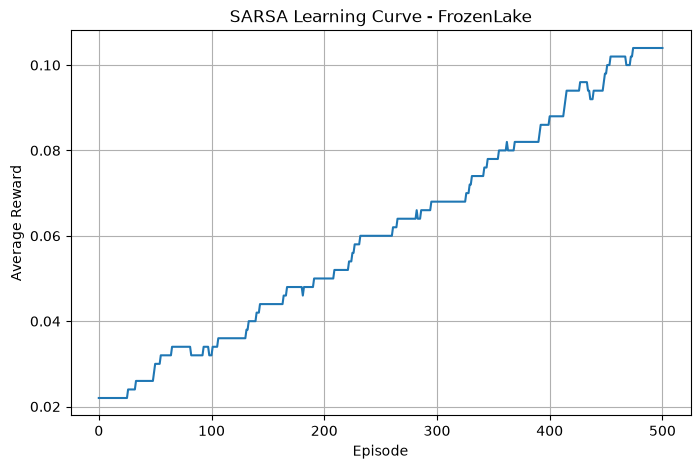

In [22]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("SARSA Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()